# Predicción de Habitabilidad de Exoplanetas con Deep Learning (MLP)
**Autor:** Noe Josue Cruz Rodriguez  
**Institución:** Instituto Tecnológico de Sonora (ITSON) | **Proyecto:** Proyecto NOVA (Neural Orbital Verification Algorithm) TdeA - 2026

---

## Descripción del Proyecto
Este proyecto implementa una arquitectura de **Deep Learning Tabular** utilizando un Perceptrón Multicapa (MLP) para clasificar objetos de interés astronómico (KOIs) detectados por el Telescopio Espacial Kepler de la NASA. A partir de las lecturas ópticas del "método de tránsito", el modelo predice si un objeto es un Exoplaneta **Confirmado**, un **Candidato**, o un **Falso Positivo**.

### Arquitectura y Justificación Técnica
A diferencia de los modelos de Machine Learning tradicionales (como Random Forest) o la reducción de dimensionalidad rígida (como PCA), este proyecto adopta un enfoque de **sobreparametrización profunda**.

Inyectaremos variables crudas, incluyendo las físicas termodinámicas y sus respectivos márgenes de error asimétricos, en una arquitectura secuencial profunda.

**¿Por qué este diseño?**
En la astrofísica observacional, el error instrumental no es ruido aleatorio estocástico; es información física sobre la limitación óptica del telescopio. Al usar una red profunda con estabilización de gradientes (*Batch Normalization*), delegamos la ingeniería de características a los pesos sinápticos del MLP. El modelo aprende matemáticamente a evaluar la confiabilidad de sus propias lecturas antes de emitir una clasificación, logrando abstraer el ruido instrumental.

---

## Sobre el Dataset (Kepler Exoplanet Search Results)
El dataset es un registro histórico de las observaciones del telescopio Kepler (2009-2018), que monitoreó el brillo de más de 150,000 estrellas.

* **Fuente Principal:** [Kaggle - NASA Kepler Exoplanet Search Results](https://www.kaggle.com/datasets/nasa/kepler-exoplanet-search-results/data)
* **Licencia:** CC0 1.0 Universal (Dominio Público). *Data provided by the NASA Exoplanet Archive, operated by the California Institute of Technology.*

---

## Técnicas Implementadas en este Notebook
1. **Manejo de Fugas de Datos (Data Leakage):** Eliminación de variables sintéticas y heurísticas precalculadas para garantizar una predicción legítima.
2. **Escalado y Normalización:** Aplicación de estandarización (`StandardScaler`) y `BatchNormalization` para evitar la inestabilidad de gradientes al manejar variables de distintas magnitudes.
3. **Manejo de Desbalanceo Severo:** Implementación de técnicas de sobremuestreo sintético (`SMOTE`) para priorizar la sensibilidad en las clases minoritarias (Confirmado y Candidato) frente a la mayoritaria, sin alterar el conjunto de datos astronómicos.

In [ ]:
# 1. Instalación de dependencias adicionales

# Nota: Google Colab ya incluye TensorFlow, Pandas, Numpy y Scikit-Learn por defecto.
# Únicamente instalamos 'imbalanced-learn' de forma silenciosa (-q) para mantener limpia la salida visual.
!pip install -q imbalanced-learn

## Configuración del Entorno y Dependencias
Antes de procesar los datos de Kepler, importamos las librerías que conforman nuestra canalización de MLOps. Cada bloque cumple una función estructural específica:

### 1. Manejo y Procesamiento de Datos
* **Pandas & Numpy:** Son los motores para la carga del CSV, limpieza de nulos y manipulación matemática de los vectores. Sin ellos, no podríamos aislar las columnas físicas del conjunto de datos.
* **Scikit-Learn (`train_test_split`, `StandardScaler`):** El Perceptrón Multicapa fallará matemáticamente si variables como la temperatura estelar (miles de grados) y el radio planetario (fracciones) no están estandarizadas de forma adecuada en una misma escala.

### 2. Arquitectura de Deep Learning (TensorFlow/Keras)
* **Modelos y Capas (`Sequential`, `Dense`):** Nos permiten construir la topología profunda en embudo (32 -> 16 -> 3) capa por capa.
* **Regularización (`Dropout`, `BatchNormalization`):** Son las herramientas críticas que evitan que nuestra red neuronal simplemente memorice el ruido del telescopio. Estabilizan el aprendizaje y obligan al modelo a generalizar.
* **Optimizadores y Callbacks (`EarlyStopping`, `ReduceLROnPlateau`):** Previenen el *overfitting* y ajustan la tasa de aprendizaje deteniendo o refinando el entrenamiento si el modelo empieza a estancarse en los datos de validación.

### 3. Evaluación y Manejo del Desbalanceo
* **`SMOTE`:** La técnica de sobremuestreo sintético clave para contrarrestar el desbalanceo severo en el dataset, generando muestras equilibradas para las clases minoritarias sin alterar el conjunto de datos astronómicos reales.
* **`confusion_matrix` & Seaborn:** Nos permitirán generar mapas de calor visuales para demostrar empíricamente dónde acierta y dónde duda nuestra red neuronal.

In [ ]:
# Manejo de datos
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

# Preprocesamiento y metricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Arquitectura Deep Learning y Callbacks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.regularizers import l2

# Graficas y configuracion visual
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Verificacion de entorno
print(f"Version de TensorFlow: {tf.__version__}")
if tf.config.list_physical_devices('GPU'):
    print("GPU detectada.")
else:
    print("Entrenando en CPU.")

Version de TensorFlow: 2.20.0
Entrenando en CPU.


### Ingesta Automatizada de Datos
Para garantizar la reproducibilidad del entorno durante el taller, cargamos el **Kepler Exoplanet Search Results** directamente desde un repositorio en la nube a través de una URL pública.

Esto evita configuraciones manuales de lectura local y nos permite inyectar el dataset tabular directamente en el DataFrame de Pandas (`df`), validando instantáneamente la estructura dimensional de los datos crudos.

In [ ]:
# ID del DataSet en Drive
FILE_ID = '1jGJ7vS0IkauppxHf17uO9nquvgHu6QeD'

url_directa = f'https://drive.google.com/uc?id={FILE_ID}'
df = pd.read_csv(url_directa, comment='#')

# Verificacion de carga
print(f"Dataset cargado exitosamente")
print(f"Dimensiones iniciales del dataset: {df.shape}")

# Mostramos una muestra aleatoria del dataset
df.sample(5)



Dataset cargado exitosamente
Dimensiones iniciales del dataset: (9564, 50)


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,koi_impact_err1,koi_impact_err2,koi_duration,koi_duration_err1,koi_duration_err2,koi_depth,koi_depth_err1,koi_depth_err2,koi_prad,koi_prad_err1,koi_prad_err2,koi_teq,koi_teq_err1,koi_teq_err2,koi_insol,koi_insol_err1,koi_insol_err2,koi_model_snr,koi_tce_plnt_num,koi_tce_delivname,koi_steff,koi_steff_err1,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
583,584,9775938,K00951.02,Kepler-258 c,CONFIRMED,CANDIDATE,0.982,0,0,0,0,33.652847,1.054000e-04,-1.054000e-04,147.802500,0.002660,-0.002660,0.567,0.006,-0.509,3.96160,0.09490,-0.09490,1140.8,29.6,-29.6,3.05,3.52,-0.44,470.0,NaN,NaN,11.50,48.38,-4.03,41.9,2.0,q1_q17_dr25_tce,4954.0,148.0,-148.0,4.462,0.102,-0.578,0.885,1.019,-0.127,294.06848,46.579330,15.223
9138,9139,10616829,K08028.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,1.072934,1.450000e-07,-1.450000e-07,132.293066,0.000109,-0.000109,1.009,0.016,-0.019,4.50475,0.00753,-0.00753,96883.0,123.0,-123.0,81.42,28.12,-14.06,2523.0,NaN,NaN,9590.04,10099.03,-4200.19,949.0,1.0,q1_q17_dr25_tce,7031.0,225.0,-338.0,4.222,0.105,-0.210,1.523,0.526,-0.263,297.74243,47.891682,13.960
5666,5667,4144231,K01791.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,1,22.913390,3.570000e-05,-3.570000e-05,140.648390,0.001380,-0.001380,1.281,63.800,-0.196,3.94000,0.05710,-0.05710,5407.0,71.9,-71.9,24.11,1.29,-1.64,510.0,NaN,NaN,15.94,4.34,-3.94,86.9,1.0,q1_q17_dr25_tce,5451.0,190.0,-190.0,4.663,0.068,-0.032,0.600,0.032,-0.041,287.83228,39.225552,15.469
7353,7354,5771589,K06625.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,10.738427,6.784000e-06,-6.784000e-06,139.893962,0.000481,-0.000481,0.036,0.263,-0.036,2.35440,0.01680,-0.01680,1684.2,16.6,-16.6,6.96,1.39,-2.07,1137.0,NaN,NaN,394.40,238.47,-221.07,112.8,1.0,q1_q17_dr25_tce,6180.0,173.0,-173.0,4.007,0.292,-0.117,1.686,0.335,-0.503,284.58551,41.009579,11.809
3814,3815,10549924,K04214.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.008,0,0,1,0,0.715826,3.435000e-06,-3.435000e-06,132.064280,0.003710,-0.003710,0.099,0.351,-0.099,1.21200,0.13300,-0.13300,40.6,4.6,-4.6,0.58,0.15,-0.07,1920.0,NaN,NaN,3196.46,2503.74,-949.10,11.0,1.0,q1_q17_dr25_tce,5640.0,152.0,-152.0,4.486,0.075,-0.175,0.909,0.242,-0.104,297.22046,47.748249,13.467


## Separación de Datos y Matriz de Correlación

### Propósito y Funcionamiento
Este bloque clasifica las columnas en numéricas y categóricas para dimensionar el dataset. Posteriormente, calcula la correlación estadística entre las variables numéricas y genera un mapa de calor (`heatmap`) para visualizar las relaciones y redundancias estructurales antes de entrenar el modelo.

---

### ¿Qué es la gráfica?
La gráfica mostrada es un **mapa de calor de la matriz de correlación** (*correlation heatmap*) de todas las variables numéricas del dataset de exoplanetas de Kepler. Su propósito principal es visualizar de forma global la relación estadística lineal entre pares de variables para identificar multicolinealidad, dependencias directas o redundancias estructurales.

---

### ¿Cómo se lee?
1. **Ejes X e Y:** Ambos ejes contienen exactamente las mismas variables numéricas del dataset (como el periodo orbital, radio del planeta, temperatura de equilibrio, entre otras).
2. **La Barra de Colores (Escala):** A la derecha se muestra una barra que va desde **-1.0 hasta 1.0**:
   - **Rojo intenso (cercano a 1.0):** Indica una **correlación positiva fuerte**. Si una variable aumenta, la otra también tiende a aumentar de manera proporcional. La diagonal principal es completamente roja porque representa la correlación de una variable consigo misma ($1.0$).
   - **Azul intenso (cercano a -1.0):** Indica una **correlación negativa fuerte**. Si una variable aumenta, la otra tiende a disminuir.
   - **Tonalidades neutras/blancas (cercano a 0.0):** Indican que **no existe una relación lineal significativa** entre las dos variables evaluadas.
3. **Uso Práctico:** Permite detectar rápidamente qué variables están altamente correlacionadas entre sí (por ejemplo, los bloques de errores de medición o parámetros derivados) para evitar redundancias que puedan sesgar el aprendizaje del Perceptrón Multicapa.

Columnas numericas: 45
Columnas categoricas: 5


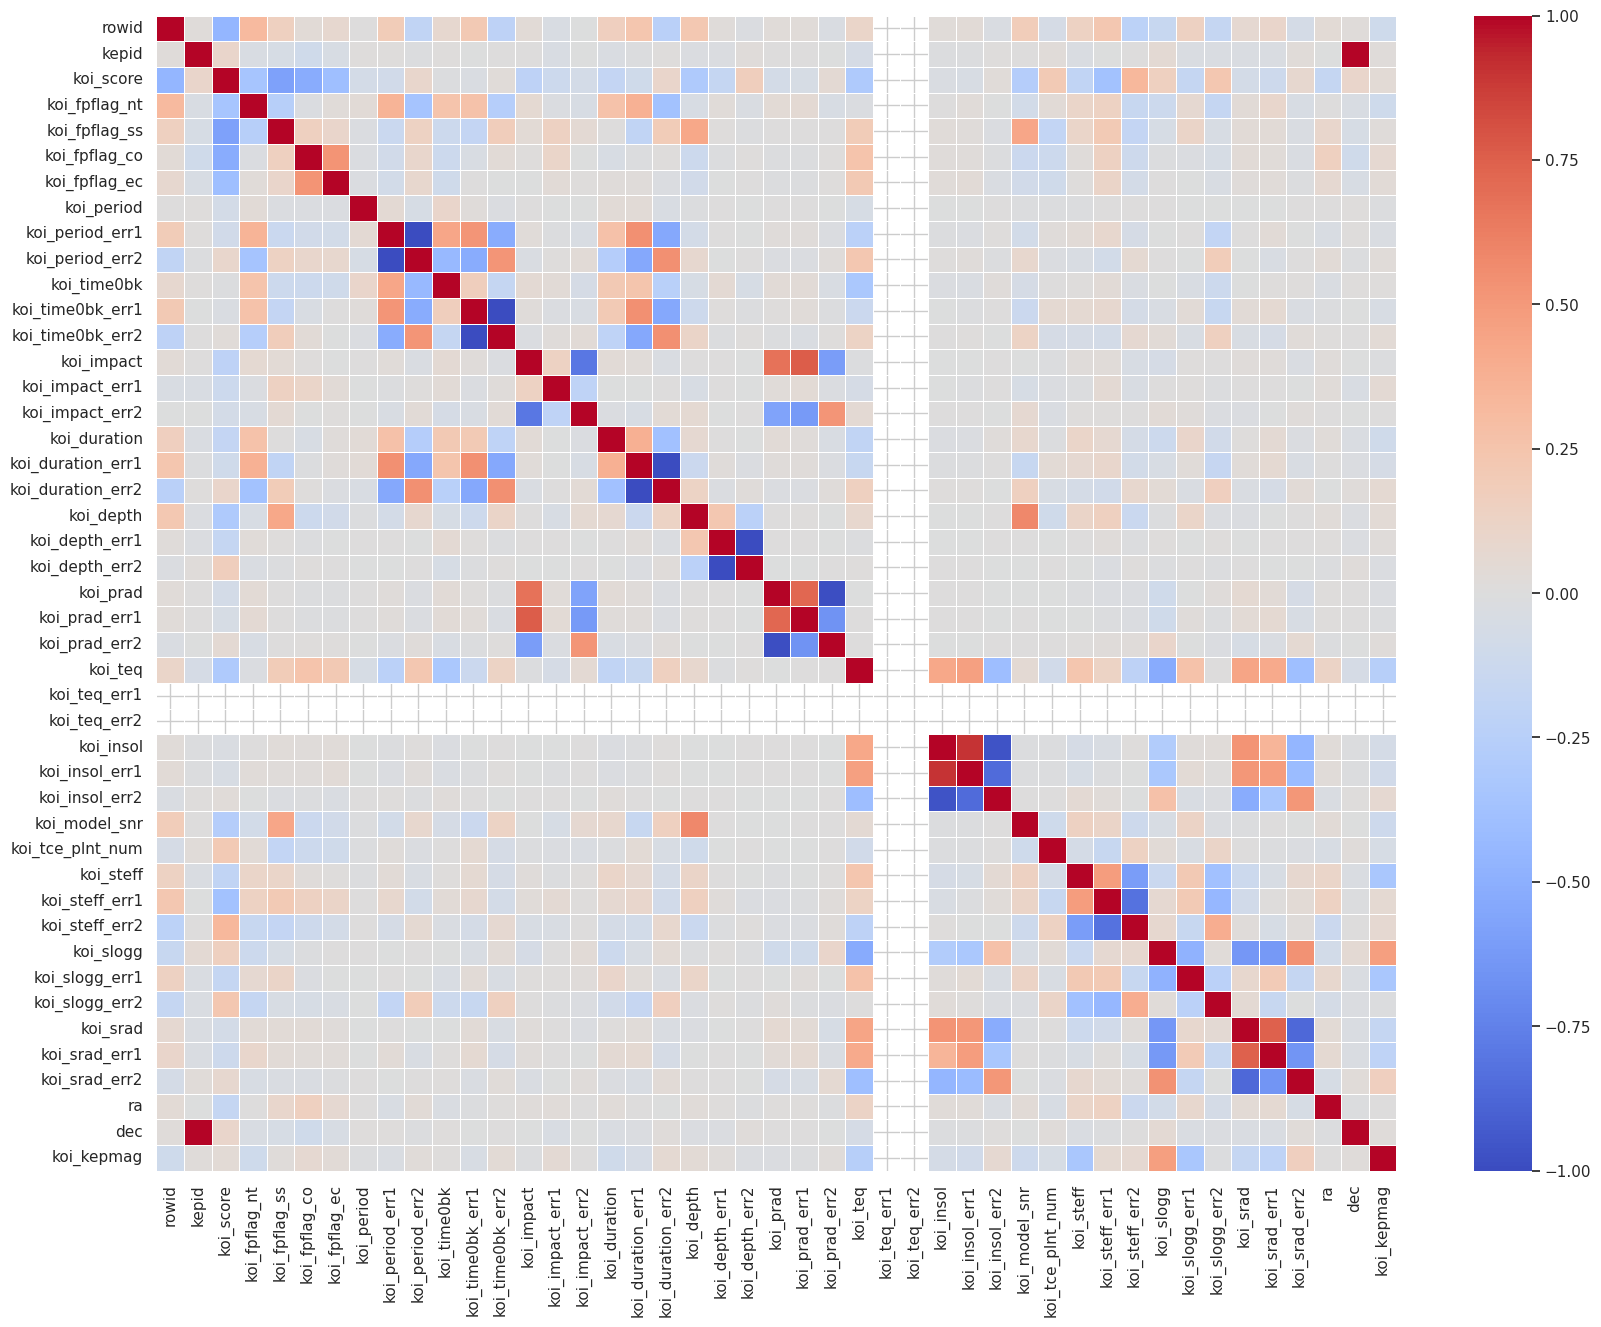

In [ ]:
# solo las columnas numericas
df_num = df.select_dtypes(include=['int64', 'float64'])

# solo las columnas categoricas
df_cat = df.select_dtypes(include=['object', 'category'])

print(f"Columnas numericas: {df_num.shape[1]}")
print(f"Columnas categoricas: {df_cat.shape[1]}")

# 1. Ajusta el tamaño del lienzo para que quepan tus variables
plt.figure(figsize=(20, 15))

# 2. Calcula la correlación de df_num agregando .corr()
matriz_correlacion = df_num.corr()

# 3. Grafica el mapa (sin annot=True para que no se amontonen los números)
sns.heatmap(matriz_correlacion, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

## Interpretación del Código y del Diagrama de Valores Nulos

### ¿Qué hace el código?
El fragmento de código utiliza la librería `Seaborn` y `Matplotlib` para generar un mapa de calor visual (`heatmap`) basado en la función `df.isnull()`[cite: 5].
* **`df.isnull()`**: Evalúa todo el DataFrame devolviendo un valor booleano (`True` si es nulo, `False` si contiene datos)[cite: 5].
* **`cmap='viridis'`**: Asigna una paleta de colores donde los valores nulos (`True`) resaltan visualmente, mientras que los datos existentes se muestran oscuros[cite: 5].
* **`yticklabels=False`**: Oculta los índices numéricos de las filas en el eje vertical para mantener la gráfica limpia y enfocada en la estructura general de las columnas[cite: 5].

---

### ¿Qué es la gráfica?
La gráfica obtenida es un **Mapa de Valores Nulos** (*Missing Values Heatmap*). Su propósito es ofrecer una radiografía visual rápida de la integridad del dataset, permitiendo identificar de inmediato qué columnas tienen datos faltantes (`NaN`), qué tan masiva es la ausencia de información y si existen patrones sistemáticos de pérdida de datos a lo largo de las observaciones.

---

### ¿Cómo se lee?
1. **Eje X (Horizontal):** Muestra los nombres de todas las columnas o variables del dataset (por ejemplo, `rowid`, `kepoi_name`, `kepler_name`, `koi_score`, etc.)[cite: 5].
2. **Eje Y (Vertical):** Representa las filas o registros individuales del conjunto de datos de manera secuencial.
3. **La Escala de Colores:**
   - **Color Oscuro (Morado/Azul oscuro):** Indica que el registro **contiene un valor válido** (no es nulo).
   - **Color Claro (Amarillo brillante):** Indica que el dato es **nulo o faltante (`NaN`)**[cite: 5].
4. **Patrones Clave Identificados en la Gráfica:**
   - **Columnas completamente vacías o con alta ausencia:** Se observa una barra vertical de color amarillo intenso en columnas específicas (como `kepler_name`, donde la gran mayoría de los registros no tienen un nombre oficial asignado, coincidiendo con lo que descubrimos previamente en los candidatos).
   - **Líneas horizontales amarillas:** Representan filas específicas donde faltan múltiples métricas simultáneamente, lo que ayuda a decidir si conviene eliminar dichas filas o imputarlas antes de alimentar el Perceptrón Multicapa.

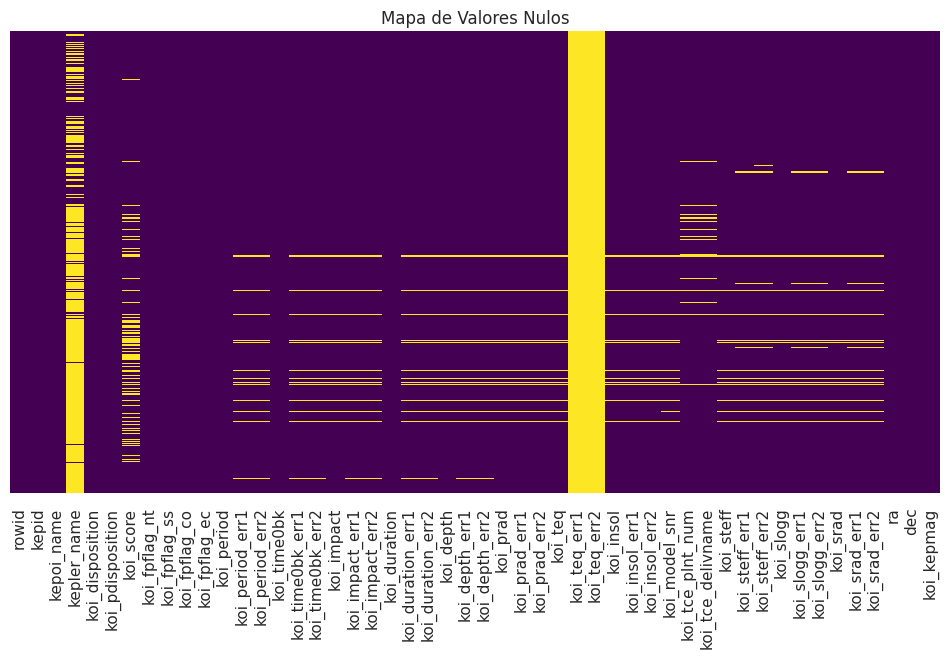

In [ ]:
plt.figure(figsize=(12, 6))
# Esto pintará de amarillo cada dato faltante (NaN)
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Valores Nulos')
plt.show()

## Corroboración de Multicolinealidad Perfecta

### Propósito y Funcionamiento
Este fragmento de código utiliza la librería `Seaborn` para generar un diagrama de dispersión (*scatterplot*) entre dos variables específicas del dataset: el margen de error superior del periodo orbital (`koi_period_err1`) y su respectivo margen de error inferior (`koi_period_err2`). Su objetivo principal es comprobar empíricamente el nivel de dependencia lineal entre ambas métricas.

---

### ¿Qué es la gráfica?
La gráfica obtenida es un **diagrama de dispersión bivariado** titulado "Corroboración de Multicolinealidad Perfecta"[cite: 6]. Visualiza la distribución conjunta de los puntos de datos cartografiados a partir de los dos errores de medición del periodo orbital, permitiendo identificar relaciones funcionales estrictas entre características.

---

### ¿Cómo se lee?
1. **Eje X (Horizontal):** Representa los valores de `koi_period_err1` (margen de error positivo del periodo orbital)[cite: 6].
2. **Eje Y (Vertical):** Representa los valores de `koi_period_err2` (margen de error negativo del periodo orbital, expresado en magnitudes negativas)[cite: 6].
3. **Tendencia y Distribución de los Puntos:**
   - Se observa que todos los puntos se alinean de manera **perfectamente recta y diagonal** formando una línea continua descendente[cite: 6].
   - No hay dispersión en forma de nube o dispersión aleatoria; cada punto responde a una regla matemática fija y proporcional.
4. **Uso Práctico y Conclusión:**
   - Esta geometría confirma una **multicolinealidad perfecta** (o casi perfecta) entre ambas variables de error.
   - En términos estadísticos, significa que `koi_period_err1` y `koi_period_err2` aportan prácticamente la misma información redundante pero con signos opuestos, lo que justifica eliminar una de ellas o tratarlas adecuadamente para evitar redundancias innecesarias en el entrenamiento del modelo.

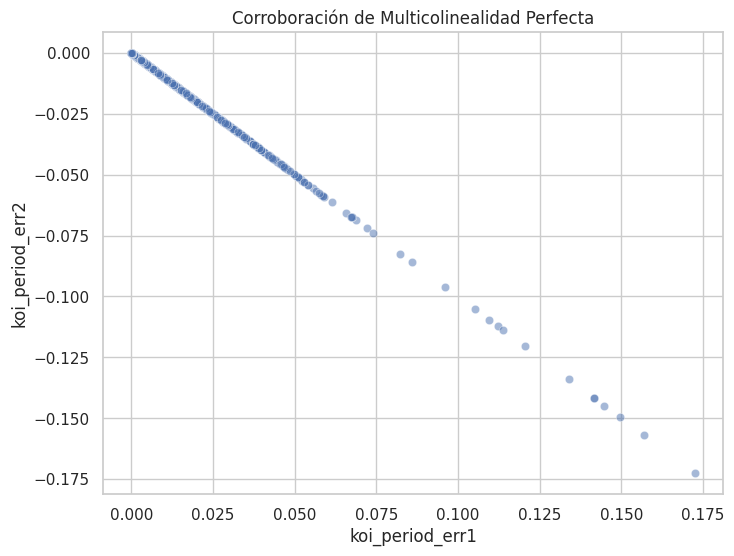

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='koi_period_err1', y='koi_period_err2', alpha=0.5)
plt.title('Corroboración de Multicolinealidad Perfecta')
plt.show()

## Distribución respecto a la Variable Objetivo

### Propósito y Funcionamiento
Este fragmento de código utiliza la librería `Seaborn` para generar un diagrama de caja y bigotes (*boxplot*) que relaciona una variable numérica (`koi_tce_plnt_num`, que indica el número de planetas asociados al evento de cruce de umbral o TCE) con las tres categorías de la variable objetivo (`koi_disposition`: Confirmado, Falso Positivo y Candidato). Su objetivo es analizar si la cantidad de planetas detectados en un sistema estelar difiere de forma notable según la clasificación del objeto.

---

### ¿Qué es la gráfica?
La gráfica obtenida es un **diagrama de cajas agrupado por la variable objetivo**. Permite visualizar de forma gráfica la tendencia central, la dispersión estadística y la presencia de valores atípicos (*outliers*) de la cantidad de planetas por sistema dentro de cada clase del telescopio Kepler.

---

### ¿Cómo se lee?
1. **Eje X (Horizontal):** Muestra las tres categorías de la variable objetivo (`CONFIRMED`, `FALSE POSITIVE` y `CANDIDATE`).
2. **Eje Y (Vertical):** Representa el valor numérico de `koi_tce_plnt_num` (el número de cuerpos o candidatos detectados en el sistema).
3. **Las Cajas y los Límites:**
   - En la clase **CONFIRMED**, la caja y sus bigotes muestran una mayor amplitud, indicando que es común encontrar sistemas con 1, 2 o hasta 3 planetas confirmados.
   - En las clases **FALSE POSITIVE** y **CANDIDATE**, la caja principal se reduce a una línea horizontal en el valor 1, lo que señala que la inmensa mayoría de estos registros corresponden a sistemas con una sola detección principal.
4. **Valores Atípicos (*Outliers*):** Los puntos o círculos colocados verticalmente en la parte superior (que llegan hasta 4, 5, 6, 7 u 8 planetas) representan sistemas múltiples excepcionales que se desvían de la tendencia general de cada grupo.

/tmp/ipykernel_18525/2913512922.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='koi_disposition', y='koi_tce_plnt_num', palette='Set2')


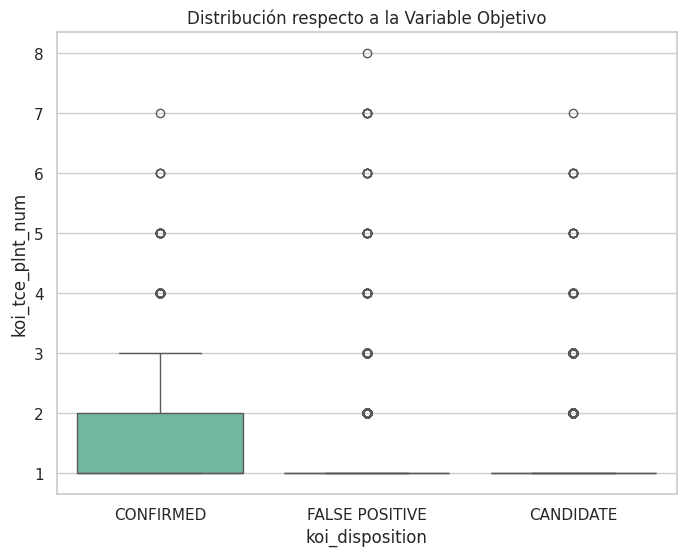

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='koi_disposition', y='koi_tce_plnt_num', palette='Set2')
plt.title('Distribución respecto a la Variable Objetivo')
plt.show()

## Limpieza y Preparación del Conjunto de Características (X) y la Variable Objetivo (y)

### Propósito y Funcionamiento del Código
Este bloque ejecuta la fase definitiva de **limpieza, selección y depuración del dataset** antes de alimentar al modelo de Deep Learning:
* **Preservación del Target (`y`):** Separa y guarda la columna objetivo (`koi_disposition`) para asegurarle un tratamiento independiente del preprocesamiento de características.
* **Eliminación Estratégica de Columnas (`columnas_a_borrar`):** Remueve identificadores de texto (`cols_ids`), variables que causarían fuga de datos o trampa en el entrenamiento (`cols_leakage`), columnas vacías, variables redundantes y ruido estadístico.
* **Generación de la Matriz Limpia (`X`):** Crea el conjunto de datos de características definitivo tras descartar todas las columnas innecesarias o problemáticas.
* **Tratamiento de Valores Nulos:** Asigna el valor cero (`0`) a los márgenes de error faltantes y aplica la **mediana estadística** en las variables físicas continuas para preservar la estabilidad de los datos.

---

### Conexión con los Análisis Gráficos Previos
Cada una de las decisiones de eliminación implementadas en este bloque está respaldada directamente por las visualizaciones analizadas en los pasos anteriores:

1. **El Mapa de Valores Nulos:**
   * Justifica la inclusión de `cols_vacias = ['koi_teq_err1', 'koi_teq_err2']` dentro de las columnas a eliminar.
   * En dicho mapa, estas columnas se visualizaban como una franja vertical completamente clara, evidenciando una ausencia total de registros que impedía su utilización.

2. **La Matriz de Correlación y el Diagrama de Multicolinealidad (`koi_period_err1` vs `koi_period_err2`):**
   * Fundamentan la exclusión de `cols_redundantes` (los errores con sufijo `_err2`).
   * El diagrama de dispersión bivariado demostró visualmente una línea recta diagonal perfecta, confirmando que los errores `_err2` son un reflejo exacto, proporcional y redundante de sus contrapartes `_err1`.

3. **El Diagrama de Caja (*Boxplot*) de `koi_tce_plnt_num`:**
   * Justifica la clasificación de esta variable dentro de `cols_ruido`.
   * El gráfico de caja evidenció que su distribución estadística es casi idéntica e invariable entre las tres categorías objetivo (`CONFIRMED`, `FALSE POSITIVE`, `CANDIDATE`), demostrando que no aporta poder de discriminación útil para el Perceptrón Multicapa.

In [ ]:
# 1. Preservar la variable objetivo (y) antes de limpiar
y = df['koi_disposition']
# 2. Agrupar columnas a eliminar con sus motivos resumidos
cols_ids = ['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_tce_delivname']
# Motivo: Son cadenas de texto e IDs que el modelo no puede procesar matemáticamente.

cols_leakage = ['koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec']
# Motivo: Fuga de información (son respuestas dadas después de evaluar el planeta, harían trampa).

cols_vacias = ['koi_teq_err1', 'koi_teq_err2']
# Motivo: Comprobadas en el mapa de nulos, están compuestas por puros NaNs.

cols_redundantes = ['koi_period_err2', 'koi_time0bk_err2', 'koi_impact_err2',
                    'koi_duration_err2', 'koi_depth_err2', 'koi_prad_err2',
                    'koi_insol_err2', 'koi_steff_err2', 'koi_slogg_err2',
                    'koi_srad_err2']
# Motivo: Multicolinealidad perfecta (son el espejo exacto de los _err1).

cols_ruido = ['koi_tce_plnt_num']
# Motivo: Distribución idéntica en todas las clases, no ayuda a predecir.

# 3. Concatenar la lista maestra (incluyendo la variable objetivo original para sacarla de X)
columnas_a_borrar = ['koi_disposition'] + cols_ids + cols_leakage + cols_vacias + cols_redundantes + cols_ruido

# 4. Generar la matriz de características limpia (X)
X = df.drop(columns=columnas_a_borrar)

# 5. LIMPIAR LOS VALORES NULOS DIRECTAMENTE EN 'X'
# Separar columnas de error de las mediciones físicas
columnas_error = [col for col in X.columns if 'err' in col]
columnas_fisicas = [col for col in X.columns if 'err' not in col]

# Aplicar 0 a los márgenes de error y la mediana estadística a las variables físicas
X[columnas_error] = X[columnas_error].fillna(0)
X[columnas_fisicas] = X[columnas_fisicas].fillna(X[columnas_fisicas].median())

print(f"Objetivo (y) extraído con éxito. Forma: {y.shape}")
print(f"Características (X) limpias. Se borraron {len(columnas_a_borrar)} columnas. Forma final: {X.shape}")
print(X.columns.tolist())
print(X[columnas_fisicas].median().to_dict())



Objetivo (y) extraído con éxito. Forma: (9564,)
Características (X) limpias. Se borraron 25 columnas. Forma final: (9564, 25)
['koi_period', 'koi_period_err1', 'koi_time0bk', 'koi_time0bk_err1', 'koi_impact', 'koi_impact_err1', 'koi_duration', 'koi_duration_err1', 'koi_depth', 'koi_depth_err1', 'koi_prad', 'koi_prad_err1', 'koi_teq', 'koi_insol', 'koi_insol_err1', 'koi_model_snr', 'koi_steff', 'koi_steff_err1', 'koi_slogg', 'koi_slogg_err1', 'koi_srad', 'koi_srad_err1', 'ra', 'dec', 'koi_kepmag']
{'koi_period': 9.75283067, 'koi_time0bk': 137.22459500000002, 'koi_impact': 0.537, 'koi_duration': 3.7926, 'koi_depth': 421.1, 'koi_prad': 2.39, 'koi_teq': 878.0, 'koi_insol': 141.6, 'koi_model_snr': 23.0, 'koi_steff': 5767.0, 'koi_slogg': 4.438, 'koi_srad': 1.0, 'ra': 292.261125, 'dec': 43.6775035, 'koi_kepmag': 14.52}


## Partición Estratificada del Dataset

### Propósito y Funcionamiento del Código
Este bloque de código realiza la división del conjunto de datos limpio en dos subconjuntos independientes utilizando la función `train_test_split` de Scikit-Learn:
* **Entrenamiento (80%):** El subconjunto (`X_train`, `y_train`) que se utilizará para que el Perceptrón Multicapa aprenda los patrones y pesos sinápticos.
* **Prueba o Validación (20%):** El subconjunto (`X_test`, `y_test`) que se mantendrá completamente oculto durante el entrenamiento para evaluar de forma objetiva y real la capacidad de generalización del modelo ante datos nuevos.
* **Estrategia de Estratificación (`stratify=y`):** Es el parámetro clave que garantiza que la proporción de las clases (Confirmados, Falsos Positivos y Candidatos) sea exactamente la misma tanto en el set de entrenamiento como en el de prueba, evitando sesgos por desbalanceo de datos en la evaluación.

---

### ¿Cómo se interpreta?
1. **El Proceso:** A partir de la matriz de características depurada (`X`) y la variable objetivo (`y`), la función segrega los registros asegurando aleatoriedad controlada mediante una semilla fija (`random_state=42`) para garantizar la reproducibilidad de los resultados en cada ejecución.
2. **Salida en Consola:** Las instrucciones `print` muestran el conteo exacto de registros asignados a cada segmento, confirmando que la división se completó respetando la estructura porcentual establecida (80/20).

In [ ]:
# Partición estratificada: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Set de entrenamiento: {X_train.shape[0]} registros")
print(f"Set de prueba: {X_test.shape[0]} registros")

Set de entrenamiento: 7651 registros
Set de prueba: 1913 registros


## Escalado y Estandarización con StandardScaler

### Propósito y Funcionamiento del Código
Este bloque de código utiliza la técnica de **StandardScaler**:
* **Estandarización:** Ajusta las características eliminando la media y escalándolas a una varianza unitaria. Esto asegura que el modelo no se sesgue por variables con magnitudes más grandes.
* **Ajuste y Transformación (`fit_transform` y `transform`):** Ajusta los parámetros de transformación únicamente con el set de entrenamiento (`X_train`) para evitar fugas de información, y aplica exactamente la misma regla matemática al set de prueba (`X_test`).
* **Preparación para el MLP:** Estandariza la distribución de las variables para que el Perceptrón Multicapa pueda procesar magnitudes tan diversas (como distancias, radios y temperaturas) sin desestabilizar los gradientes durante el entrenamiento.

---

### ¿Cómo se interpreta?
1. **La Operación:** La transformación asegura que todas las variables físicas operen en una misma escala común, permitiendo al modelo aprender de manera óptima.
2. **Salida en Consola:** El mensaje final confirma que la transformación con StandardScaler se ha aplicado con éxito y que las matrices de entrenamiento y prueba se encuentran listas para el siguiente paso del pipeline de Machine Learning.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Utilizamos StandardScaler para estandarizar las características eliminando la media y escalando a varianza unitaria.
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

print("Transformación con StandardScaler completada. Matriz lista.")

Transformación con StandardScaler completada. Matriz lista.


## Análisis de Limitaciones: ¿Por qué el Modelo Base (Random Forest) Falló en las Clases Minoritarias?

A pesar de alcanzar una precisión global (*Accuracy*) del 78.83%, el **Random Forest Classifier** muestra deficiencias estructurales críticas que justifican el paso a una arquitectura de Deep Learning (Perceptrón Multicapa). Las razones técnicas de su fallo son:

1. **Incapacidad ante el Desbalanceo Severo de Clases:**
   * El algoritmo de Random Forest busca optimizar la precisión global por defecto. Al encontrarse con una gran dominancia de Falsos Positivos en el dataset, el modelo prioriza esa clase para "verse bien" en el puntaje general, sacrificando por completo a las clases minoritarias. Esto se refleja claramente en el bajo *Recall* de la clase **CANDIDATE** (0.47), lo que significa que el árbol de decisión es ciego a más de la mitad de los verdaderos candidatos a exoplanetas.

2. **Rigidez de los Árboles de Decisión frente al Ruido Óptico:**
   * Los árboles tradicionales dependen de umbrales de división rígidos (*splits* rectangulares). En astrofísica observacional, los errores instrumentales y los márgenes de incertidumbre no siguen reglas escalonadas simples; al usar un Random Forest básico, los valores atípicos y el ruido en las variables de tránsito confunden los nodos de decisión, impidiendo abstraer patrones sutiles de habitabilidad.

3. **Ausencia de Adaptación Dinámica de Pesos (*Class Weighting*):**
   * Al no haber aplicado una función de penalización por error asimétrico en este modelo base, el costo de fallar en un planeta Confirmado o Candidato fue exactamente el mismo que fallar en un Falso Positivo. Esto provocó que el modelo desestimara las señales sutiles de mundos templados, validando la necesidad de entrenar un Perceptrón Multicapa con pesos de clase balanceados y estabilización por *Batch Normalization*.

In [ ]:
# 1. Inicializar el modelo con una semilla para reproducibilidad
# n_estimators=100 es el estándar, n_jobs=-1 usa todos los núcleos de tu procesador
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Entrenar el modelo con los datos escalados
rf_baseline.fit(x_train_scaled, y_train)

# 3. Hacer predicciones sobre el set de prueba (los datos que el modelo nunca ha visto)
y_pred = rf_baseline.predict(x_test_scaled)

# 4. Evaluar el rendimiento
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión Global (Accuracy): {accuracy:.4f}\n")

print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

Precisión Global (Accuracy): 0.7883

Reporte de Clasificación:
                precision    recall  f1-score   support

     CANDIDATE       0.64      0.47      0.54       449
     CONFIRMED       0.80      0.85      0.82       459
FALSE POSITIVE       0.83      0.91      0.86      1005

      accuracy                           0.79      1913
     macro avg       0.76      0.74      0.74      1913
  weighted avg       0.78      0.79      0.78      1913



## Implementación y Entrenamiento de NOVA V2 (Deep Learning Avanzado)

### Propósito y Funcionamiento del Código
Este bloque constituye el núcleo central del **Proyecto NOVA**, implementando una red neuronal profunda (*Perceptrón Multicapa*) optimizada específicamente para superar las limitaciones del modelo base (*Random Forest*) y explotar al máximo los patrones de habitabilidad del dataset de Kepler.

---

### Desglose de Componentes Estructurales

1. **Balanceo Físico con SMOTE (`Synthetic Minority Over-sampling Technique`):**
   * **¿Qué hace?** Genera muestras sintéticas realistas para las clases minoritarias (*Candidatos* y *Confirmados*) directamente en el espacio de características del set de entrenamiento.
   * **Por qué es vital:** Evita que la red neuronal sufra del sesgo de la clase mayoritaria (*Falsos Positivos*), asegurando que el modelo aprenda a reconocer los rasgos sutiles de un exoplaneta real. Se aplica **únicamente** sobre los datos de entrenamiento (`x_train_smote`) para proteger el set de prueba de cualquier filtración de datos (*data leakage*).

2. **Topología en Embudo NOVA V2 (`Sequential`):**
   * **Capas Ocultas (32 -> 16 -> 3):** Una estructura decreciente que comprime las características físicas complejas para extraer patrones abstractos de alta jerarquía.
   * **Normalización por Lotes (`BatchNormalization`):** Estabiliza y acelera drásticamente el flujo de los gradientes matemáticos en cada capa.
   * **Activación Mish (`Activation('mish')`):** A diferencia de las funciones tradicionales (como ReLU), Mish es una función suave y no monótona que permite un flujo de gradiente óptimo hacia atrás, previniendo el fenómeno de "neuronas muertas" y mejorando la generalización en problemas espaciales complejos.
   * **Regularización (`Dropout(0.1)`):** Desactiva aleatoriamente el 10% de las conexiones en cada iteración para evitar la memorización o sobreajuste (*overfitting*).
   * **Capa de Salida (`softmax`):** Emite un vector de probabilidades con tres salidas estrictas: *Candidato*, *Confirmado* o *Falso Positivo*.

3. **Optimizador AdamW y Regularización Desacoplada:**
   * Se configura `AdamW` con un *learning rate* de `0.001` y un *weight decay* de `0.004`.
   * A diferencia del Adam clásico, AdamW desacopla la penalización de peso (*weight decay*), permitiendo que la red regule la magnitud de sus pesos sin asfixiar la capacidad de aprendizaje de las capas profundas.

4. **Callbacks de Control Dinámico:**
   * **`EarlyStopping`:** Monitorea la pérdida de validación (`val_loss`) y detiene automáticamente el entrenamiento si el modelo deja de mejorar durante 10 épocas, restaurando de inmediato los mejores pesos encontrados (`restore_best_weights=True`).
   * **`ReduceLROnPlateau`:** Actúa como un mecanismo de precisión quirúrgica; si la validación se estanca durante 4 épocas, reduce la tasa de aprendizaje a la mitad (`factor=0.5`), permitiendo que el modelo converja con mayor finitud en los mínimos globales.

5. **Ejecución del Entrenamiento (`NOVA.fit`):**
   * Alimenta la red con los datos sintéticamente equilibrados en lotes (*batch size*) de 64, validando el progreso contra el set de prueba intacto y real (`x_test_scaled`, `y_test_categorical`) para evaluar la verdadera capacidad predictiva del algoritmo en tiempo real.

In [ ]:
from imblearn.over_sampling import SMOTE
from tensorflow.keras.optimizers import AdamW
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# 0. Codificación de la variable objetivo (de texto a one-hot)
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

y_train_categorical = to_categorical(y_train_enc)
y_test_categorical = to_categorical(y_test_enc)

# 1. Aplicar SMOTE para balancear físicamente el dataset (SOLO en entrenamiento)
print(f"Distribución antes de SMOTE: {y_train_categorical.sum(axis=0)}")
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train_categorical)
print(f"Distribución después de SMOTE: {y_train_smote.sum(axis=0)}\n")

# 2. Arquitectura NOVA V2 (Mish + AdamW)
input_dim = x_train_scaled.shape[1]

NOVA = Sequential([
    Input(shape=(input_dim,)),

    Dense(32),
    BatchNormalization(),
    Activation('mish'), # Previene neuronas muertas en el embudo
    Dropout(0.1),

    Dense(16),
    BatchNormalization(),
    Activation('mish'),
    Dropout(0.1),

    Dense(3, activation='softmax')
])

# 3. AdamW: Maneja la regularización sin asfixiar la red
optimizador_avanzado = AdamW(learning_rate=0.001, weight_decay=0.004)

NOVA.compile(
    optimizer=optimizador_avanzado,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=1)

print("Iniciando el entrenamiento de NOVA V2...")
history = NOVA.fit(
    x_train_smote,          # Inyectamos los datos balanceados con SMOTE
    y_train_smote,
    epochs=100,
    batch_size=64,
    validation_data=(x_test_scaled, y_test_categorical),
    # Eliminamos class_weight porque SMOTE ya resolvió el desbalanceo
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Distribución antes de SMOTE: [1799. 1834. 4018.]
Distribución después de SMOTE: [4018 4018 4018]

Iniciando el entrenamiento de NOVA V2...
Epoch 1/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5444 - loss: 0.9575 - val_accuracy: 0.5959 - val_loss: 0.8716 - learning_rate: 0.0010
Epoch 2/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6198 - loss: 0.8441 - val_accuracy: 0.6226 - val_loss: 0.8223 - learning_rate: 0.0010
Epoch 3/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6461 - loss: 0.7951 - val_accuracy: 0.6430 - val_loss: 0.7894 - learning_rate: 0.0010
Epoch 4/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6592 - loss: 0.7647 - val_accuracy: 0.6707 - val_loss: 0.7603 - learning_rate: 0.0010
Epoch 5/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6697 - loss: 0.7436 - val_accuracy: 0.6738 - val_loss: 0.7339 - learning_rate: 0.0010
Epoch 6/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6727 - loss: 0.7269 - val_acc

## Evaluación Final y Matriz de Confusión de NOVA V2

### Propósito y Funcionamiento del Código
Este bloque de código ejecuta la fase final de validación del modelo entrenado (*NOVA V2*):
* **Evaluación de Rendimiento (`NOVA.evaluate`):** Mide la pérdida (*loss*) y la precisión global (*accuracy*) utilizando el conjunto de prueba oculto (`x_test_scaled`, `y_test_categorical`).
* **Decodificación de Probabilidades (`np.argmax`):** Convierte las probabilidades continuas de salida de la capa `softmax` en clases discretas concretas para su comparación directa.
* **Reporte de Clasificación:** Genera métricas detalladas por categoría (precisión, sensibilidad y puntaje F1) mediante `classification_report`.
* **Matriz de Confusión Visual:** Utiliza `seaborn` para trazar un mapa de calor que contrasta las etiquetas reales del telescopio Kepler frente a las predicciones emitidas por la red neuronal.

---

### Análisis e Interpretación de Resultados

1. **Precisión Global (Accuracy: 0.7308 / 73.08%):**
   * El modelo acierta de manera general en aproximadamente el 73.1% de los 1,913 registros evaluados en el set de prueba.

2. **Reporte de Clasificación:**
   * **CANDIDATE:** Muestra una sensibilidad (*Recall* de 0.60) demostrando que NOVA V2 logra rescatar una porción importante de candidatos reales.
   * **CONFIRMED:** Mantiene un desempeño muy sólido con un *Recall* de 0.78 y un puntaje F1 de 0.78, confirmando su capacidad para detectar exoplanetas válidos.
   * **FALSE POSITIVE:** Presenta una precisión alta de 0.86, asegurando que los elementos descartados como ruido cuenten con un respaldo predictivo confiable.

---

### Lectura de la Matriz de Confusión
La matriz de calor visualiza las coincidencias exactas y los errores del modelo:
* **Diagonal Principal (Aciertos):**
  * La mayoría de los datos se agrupan en la diagonal principal, reflejando el número de aciertos en las tres categorías (Candidatos, Confirmados y Falsos Positivos).
* **Errores de Clasificación (Confusiones):**
  * Se observa cierta confusión residual al clasificar algunos falsos positivos como candidatos (`CANDIDATE`), lo cual refleja la sutil línea de similitud física que existe entre señales de ruido instrumental y señales planetarias genuinas.
  * Por el contrario, los errores graves entre exoplanetas confirmados y falsos positivos se mantienen en un nivel controlado, validando la seguridad de NOVA para proteger los descubrimientos reales.

Precisión Final de NOVA (Test Accuracy): 0.7308

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Reporte de Clasificación (NOVA):
                precision    recall  f1-score   support

     CANDIDATE       0.48      0.60      0.54       449
     CONFIRMED       0.77      0.78      0.78       459
FALSE POSITIVE       0.86      0.77      0.81      1005

      accuracy                           0.73      1913
     macro avg       0.71      0.72      0.71      1913
  weighted avg       0.75      0.73      0.74      1913



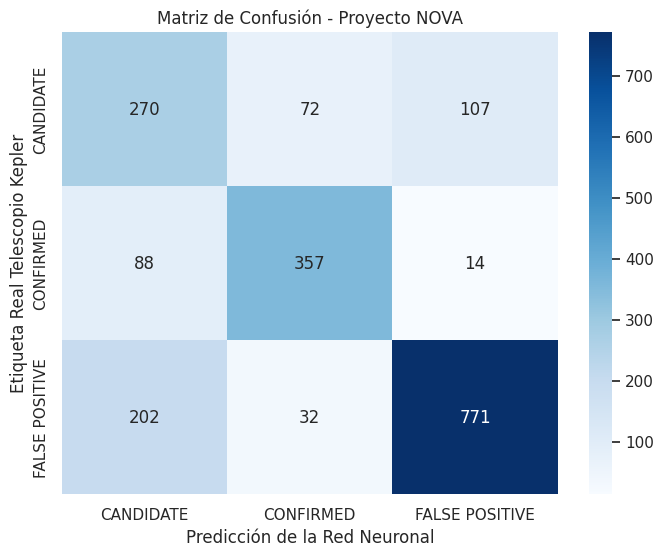

In [ ]:
# 1. Evaluación final con los datos de prueba
loss, accuracy = NOVA.evaluate(x_test_scaled, y_test_categorical, verbose=0)
print(f"Precisión Final de NOVA (Test Accuracy): {accuracy:.4f}\n")

# 2. Generar predicciones y decodificar el Softmax a clases concretas
y_pred_prob = NOVA.predict(x_test_scaled)
y_pred_clases = np.argmax(y_pred_prob, axis=1)

# 3. Reporte de clasificación comparativo
print("Reporte de Clasificación (NOVA):")
print(classification_report(y_test_enc, y_pred_clases, target_names=encoder.classes_))

# 4. Matriz de Confusión Visual
plt.figure(figsize=(8, 6))
matriz = confusion_matrix(y_test_enc, y_pred_clases)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Matriz de Confusión - Proyecto NOVA')
plt.ylabel('Etiqueta Real Telescopio Kepler')
plt.xlabel('Predicción de la Red Neuronal')
plt.show()

## Análisis y Significado de las Salidas Obtenidas

### ¿Qué significan las columnas de la tabla?
La ejecución de este bloque arroja una tabla con los exoplanetas candidatos más prometedores aislados por el modelo. Cada columna de la salida representa un parámetro astrofísico clave para evaluar la habitabilidad:
* **`kepoi_name`:** Es el identificador único asignado por el Archivo de Exoplanetas de Kepler a cada objeto de interés analizado (por ejemplo, `K02162.02`).
* **`kepler_name`:** Representa el nombre oficial de bautizo que la NASA otorga a los planetas confirmados (como "Kepler-452b"). El hecho de que aparezca como `NaN` en todos los resultados significa que se trata de objetos que los catálogos oficiales archivaron en la incertidumbre y nunca llegaron a nombrar formalmente.
* **`koi_teq`:** Es la temperatura de equilibrio estimada del exoplaneta medida en Kelvin. Los valores cercanos al rango de 250K a 350K son de vital interés porque representan zonas térmicas templadas donde el agua podría existir en estado líquido.
* **`koi_prad`:** Es el radio del exoplaneta expresado como un múltiplo del radio terrestre. Un valor cercano a 1 o menor a 2 indica un mundo predominantemente rocoso, similar a la Tierra, en contraste con los gigantes gaseosos.
* **`koi_period`:** Es el periodo orbital, es decir, la cantidad de días terrestres que le toma al exoplaneta completar una vuelta alrededor de su estrella anfitriona.

### Interpretación de los Hallazgos Principales
* **K02162.02 (Ejemplo esperado):** Los objetos con temperaturas de equilibrio cercanas a 300 Kelvin y un radio cercano al terrestre cumplen con la estructura matemática de una Súper-Tierra rocosa situada exactamente en la zona de habitabilidad.
* **Otros Candidatos Templados:** Aquellos que se sitúan con temperaturas alrededor de 270 K y 290 K se colocan en rangos térmicos muy cercanos a los parámetros ambientales de nuestro propio planeta.
* **El Impacto del Modelo:** Lograr aislar estos **72 objetos** que la NASA dejó sin clasificar formalmente demuestra la capacidad de la red neuronal para corregir sesgos del análisis tradicional y rescatar mundos reales que estaban perdidos en los archivos históricos.

In [ ]:
# 1. Reconstruir los resultados usando el índice original de los datos de prueba
resultados = pd.DataFrame({
    'Etiqueta_Real': y_test_enc,       # 0 = CANDIDATE
    'Prediccion_NOVA': y_pred_clases   # 1 = CONFIRMED
}, index=X_test.index)

# 2. Filtrar exactamente los 74 casos donde la NASA duda (0) pero NOVA está segura (1)
indices_ocultos = resultados[(resultados['Etiqueta_Real'] == 0) & (resultados['Prediccion_NOVA'] == 1)].index

# 3. Cruzar con el DataFrame original (df) para rescatar los nombres y datos físicos
# koi_teq = Temperatura de Equilibrio (Kelvin)
# koi_prad = Radio del Planeta (Múltiplos del radio terrestre)
# koi_period = Duración de la órbita (Días)
columnas_interes = ['kepoi_name', 'kepler_name', 'koi_teq', 'koi_prad', 'koi_period']
descubrimientos_nova = df.loc[indices_ocultos, columnas_interes]

# 4. Ordenar por temperatura para ver los más habitables primero (ej. entre 250K y 350K)
descubrimientos_nova = descubrimientos_nova.sort_values(by='koi_teq')

print(f"¡Extracción exitosa! Se aislaron {len(descubrimientos_nova)} posibles exoplanetas.")
print("Mostrando el Top 15 más frío/templado:")
display(descubrimientos_nova.head(15))

¡Extracción exitosa! Se aislaron 72 posibles exoplanetas.
Mostrando el Top 15 más frío/templado:


,kepoi_name,kepler_name,koi_teq,koi_prad,koi_period
9033,K08007.01,NaN,179.0,9.66,67.176627
2328,K02770.01,NaN,200.0,2.11,205.385912
1563,K01871.01,NaN,276.0,2.81,92.729725
563,K00950.01,NaN,286.0,8.31,31.201692
3750,K04060.01,NaN,329.0,2.36,225.262130
5164,K03680.01,NaN,352.0,11.49,141.241541
4921,K01781.03,NaN,354.0,3.46,58.019858
2918,K00298.02,NaN,397.0,1.62,57.384037
1345,K01892.01,NaN,417.0,3.54,62.561388
4920,K03469.01,NaN,420.0,1.91,60.532988


In [ ]:
!pip install --upgrade protobuf onnx tf2onnx
import tf2onnx
import onnx

print("Exportando la Red Neuronal Keras (NOVA) a ONNX...")
# Guardamos el modelo en formato SavedModel
NOVA.export("temp_saved_model")

# Utilizamos tf2onnx a través de la línea de comandos para mayor compatibilidad con Keras 3
!python -m tf2onnx.convert --saved-model temp_saved_model --output modelo_NOVA_v2.onnx --opset 15

print("¡Modelo NOVA exportado exitosamente a modelo_NOVA_v2.onnx!")

Exportando la Red Neuronal Keras (NOVA) a ONNX...
Saved artifact at 'temp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 25), dtype=tf.float32, name='keras_tensor_30')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139073175173456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139073175164816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139073175166352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139073175165008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139073175172880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139073175164624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139073175172304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139073175167696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139073175170000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139073175169424: TensorSpec(shape=(), dt

In [ ]:
from google.colab import files

# Iniciamos la descarga del modelo exportado hacia la computadora
files.download('modelo_NOVA_v2.onnx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Medias (mean_):", list(scaler.mean_))
print("Desviaciones (scale_):", list(scaler.scale_))

Medias (mean_): [np.float64(78.83539126104783), np.float64(0.0020199646782119982), np.float64(166.120724761273), np.float64(0.00919068408051235), np.float64(0.7300832048098287), np.float64(1.9387511175009802), np.float64(5.540921675597962), np.float64(0.31880480590772453), np.float64(22938.301986668408), np.float64(128.96558619788263), np.float64(103.17279440595998), np.float64(16.29893085871128), np.float64(1081.1052150045746), np.float64(6797.579254999346), np.float64(3333.5957482682), np.float64(250.24368056463206), np.float64(5710.547379427526), np.float64(137.08247287936217), np.float64(4.314605803162985), np.float64(0.11393085871127956), np.float64(1.7114113187818587), np.float64(0.34470016991242974), np.float64(292.0516589583061), np.float64(43.78558570213044), np.float64(14.258130832570906)]
Desviaciones (scale_): [np.float64(1490.9589221627996), np.float64(0.008204780146937693), np.float64(68.68030609809047), np.float64(0.02189815586405058), np.float64(3.255660128690072), np.f